# ESTIMATE stromal and immune scores

**ESTIMATE 基质与免疫评分**

Calculate stromal, immune and combined ESTIMATE scores for the STAD RNA-seq example.

This notebook uses public [IOBR release fixtures](https://github.com/IOBR/IOBR/releases/tag/data-v1.0). Source URLs and checksums are in [data/manifest.json](data/manifest.json). Figures are descriptive; no clinical outcome labels are supplied.

**Setup:** from the repository root, install with `python -m pip install ".[tutorials]"`. Restart the notebook kernel after installation.

In [1]:
%matplotlib inline
from pathlib import Path
from time import perf_counter
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import iobrx

# Works from the repository root or from the tutorials directory.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tutorials" / "_common.py").exists())
sys.path.insert(0, str(ROOT / "tutorials"))
from _common import (configure, load, tpm_input, runtime_info, numeric_scores,
                     short_samples, clean_labels, panel, heatmap, scatter,
                     stacked, composition_figure, fractions, save_figure, save_result, COLORS, TEAL, RUST, NAVY)
configure(2)
iobrx.set_threads(8)
display(runtime_info())


{'iobrx': '0.2.0',
 'threads': 8,
 'native_available': True,
 'native_reason': None,
 'sorting': 'numpy CPU dispatch',
 'requires_avx512': False,
 'bundled_openblas_found': True,
 'versions': {'numpy': '2.2.6',
  'pandas': '2.3.3',
  'scipy': '1.16.3',
  'scikit-learn': '1.7.2',
  'iobrpy': '0.2.1',
  'gseapy': '1.3.1',
  'matplotlib': '3.10.9'}}

## 1. Inspect the input / 检查输入

Expression matrices are **genes × samples**. The analysis uses every sample; any figure subset is stated explicitly.

In [2]:
tpm = tpm_input()
log_expression = np.log2(tpm + 1)
input_shape = log_expression.shape
display(log_expression.iloc[:5, :4])


,TCGA-BR-6455,TCGA-BR-7196,TCGA-BR-8371,TCGA-BR-8380
MT-CO1,14.615317,14.554167,15.853313,15.614422
MT-ND4,13.826380,13.869297,15.556646,14.974152
MT-CO3,13.605734,13.856893,15.538424,15.076831
IGKC,13.272941,16.263435,9.480865,12.094692
MT-CO2,13.657499,13.673317,15.038991,14.393957


## 2. Run the analysis / 运行分析

The timer covers the call below, including its resource setup. Data loading above and plotting below are excluded. This is a single run; repeated benchmark medians are reported separately in the README.

In [3]:
started = perf_counter()
result = iobrx.estimate_score(log_expression, platform="rnaseq")
elapsed = perf_counter() - started
display(save_result(result, "11_estimate", elapsed, input_shape))

 Starting estimate_score
Merged dataset includes 10141 genes.
 Gene set 'StromalSignature' overlap: 138 genes
 Gene set 'ImmuneSignature' overlap: 140 genes
Completed in 0.033 s; input 48,058 features × 10 samples.


,analysis,seconds,input_shape,output_shapes,threads
0,11_estimate,0.03275,"[48058, 10]","{'result': [3, 10]}",8


In [4]:
display(result.head() if isinstance(result, pd.DataFrame) else {key: value.shape if isinstance(value, pd.DataFrame) else list(value) for key, value in result.items()})

,TCGA-BR-6455,TCGA-BR-7196,TCGA-BR-8371,TCGA-BR-8380,TCGA-BR-8592,TCGA-BR-8686,TCGA-BR-A4IV,TCGA-BR-A4J4,TCGA-BR-A4J9,TCGA-FP-7916
StromalSignature,285.543209,1343.686744,614.047049,955.943542,1350.740153,789.804423,1523.059665,165.640126,807.360608,1006.519031
ImmuneSignature,1411.544601,1854.169320,1379.664329,688.615081,1518.457612,2146.930245,856.849361,1094.049893,1007.310226,2336.341828
ESTIMATEScore,1697.087810,3197.856063,1993.711379,1644.558623,2869.197765,2936.734668,2379.909026,1259.690020,1814.670834,3342.860860


## 3. Visualize and export / 作图与导出

White background, restrained colors, thin axes and editable vector text. Display transformations do not overwrite the analysis result. `S01`, `S02`, … follow the input sample order, as recorded in the mapping table below.

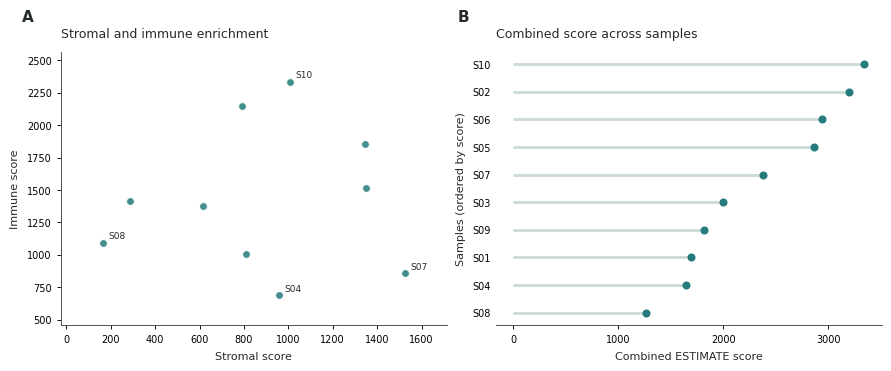

In [5]:
stromal = next(name for name in result.index if "stromal" in str(name).lower())
immune = next(name for name in result.index if "immune" in str(name).lower())
fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.6), layout="constrained")
scatter(axes[0], result.loc[stromal].to_numpy(), result.loc[immune].to_numpy(), "Stromal score", "Immune score", annotate=True)
total = result.loc["ESTIMATEScore"]
order = np.argsort(total.to_numpy())
labels = np.array(short_samples(total.index))[order]
axes[1].hlines(np.arange(len(order)), 0, total.iloc[order], color="#CBD9D7", linewidth=2)
axes[1].scatter(total.iloc[order], np.arange(len(order)), s=23, c=TEAL, zorder=3)
axes[1].set_yticks(np.arange(len(order)), labels)
axes[1].set(xlabel="Combined ESTIMATE score", ylabel="Samples (ordered by score)")
axes[1].spines["left"].set_visible(False)
axes[1].tick_params(axis="y", length=0)
axes[1].set_xticks([0, 1000, 2000, 3000])
panel(axes[0], "A", "Stromal and immune enrichment")
panel(axes[1], "B", "Combined score across samples")
save_figure(fig, '11_estimate')


In [6]:
sample_ids = expression.columns if "expression" in globals() else counts.columns if "counts" in globals() else tpm.columns
display(pd.DataFrame({"plot_label": short_samples(sample_ids), "original_sample_id": sample_ids}).head(30))

,plot_label,original_sample_id
0,S01,TCGA-BR-6455
1,S02,TCGA-BR-7196
2,S03,TCGA-BR-8371
3,S04,TCGA-BR-8380
4,S05,TCGA-BR-8592
5,S06,TCGA-BR-8686
6,S07,TCGA-BR-A4IV
7,S08,TCGA-BR-A4J4
8,S09,TCGA-BR-A4J9
9,S10,TCGA-FP-7916


## 4. Interpretation and limits / 解读与边界

These are enrichment scores, not cell percentages. Only the exact upstream platform string 'affymetrix' requests its calibrated tumor-purity transformation; 'affy' does not. This RNA-seq tutorial deliberately shows scores without applying the Affymetrix purity calibration.

**Reusing this tutorial:** replace the input-loading cell with your own `pd.read_csv(..., index_col=0)`; keep the matrix orientation, identifier type and expression scale consistent with this example. Check gene overlap before interpreting estimates.

Figures are written to `tutorials/figures/11_estimate.png`, `.pdf`, and `.svg`. Compact output tables and timing metadata are written to `tutorials/results/`. Large count/TPM matrices remain in `result`; save them explicitly with `result.to_parquet(...)` if needed.